### Importing Libraries

In [3]:
import pandas as pd

In [4]:
print("Libraries ready to import")


Libraries ready to import


In [5]:
import sys
!{sys.executable} -m pip install requests

In [6]:
import requests
print("Requests is working!")

Requests is working!


In [7]:
import sys
!{sys.executable} -m pip install beautifulsoup4

In [8]:
from bs4 import BeautifulSoup
print("BeautifulSoup is working!")

BeautifulSoup is working!


In [9]:
import sys
!{sys.executable} -m pip install selenium

In [10]:
from selenium import webdriver
print("Selenium is working!")

Selenium is working!


In [11]:
import time ### time helps you add delays 

# #### HTTP & HTML parsing
import requests
from bs4 import BeautifulSoup

# # Browser automation (Selenium)
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By

In [12]:
import sys
!{sys.executable} -m pip install webdriver-manager

In [13]:
from webdriver_manager.chrome import ChromeDriverManager

In [14]:
# Configure Chrome options (Launch an headless browser)
chrome_options = Options()
chrome_options.add_argument("--headless")          
chrome_options.add_argument("--no-sandbox")         
chrome_options.add_argument("--disable-dev-shm-usage")  
chrome_options.add_argument("--disable-gpu")       
chrome_options.add_argument("--window-size=1920,1080")  

# A realistic User-Agent prevents some anti-bot measures from triggering
chrome_options.add_argument(
    "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/122.0.0.0 Safari/537.36"
)

service = Service(ChromeDriverManager().install())

driver = webdriver.Chrome(service=service, options=chrome_options)

print("Browser launched successfully!")
print(f"Chrome version: {driver.capabilities['browserVersion']}")

Browser launched successfully!
Chrome version: 146.0.7680.178


In [15]:
from selenium.webdriver.support.ui import WebDriverWait

In [16]:
from selenium.webdriver.support import expected_conditions as EC

## Part 1: BeautifulSoup (CoinGecko)
Using what you learned from scraping CoinGecko:\
Scrape the top 50 coins from CoinGecko and save the raw data to a CSV\
Clean the numeric columns (price, market cap, volume, % changes)\
Answer these questions using pandas:\
Which coin had the biggest 24h gain?\
Which coin had the biggest 24h loss?\
What is the total market cap of the top 50 coins combined?\
How many coins are down over 7 days?\
Create two matplotlib charts of your choice that tell a story about the data. Each chart must have a title, labelled axes.


In [17]:
URL = "https://www.coingecko.com"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/122.0.0.0 Safari/537.36"
    )
}

response = requests.get(URL, headers=headers, timeout=15)

print(f"Status code: {response.status_code}")
print(f"Page size:   {len(response.text):,} characters")

Status code: 200
Page size:   1,639,676 characters


In [18]:
soup = BeautifulSoup(response.text, "html.parser")

print("Page title:", soup.title.text.strip())

table = soup.find("table")
if table:
    print("Table found!")
    rows = table.find_all("tr")
    print(f"Rows found: {len(rows)}")
else:
    print("No table found.")

Page title: Cryptocurrency Prices, Charts, and Crypto Market Cap | CoinGecko
Table found!
Rows found: 101


In [34]:
coin_data = []

tbody = table.find("tbody") if table else None

if tbody:
    for row in tbody.find_all("tr")[:50]:
        cells = row.find_all("td")
        if len(cells) < 8:
            continue

        rank        = cells[1].get_text(strip=True)
        
        name_cell   = cells[2].get_text(separator="|", strip=True).split("|")
        name        = name_cell[0] if name_cell else ""
        ticker      = name_cell[1] if len(name_cell) > 1 else ""
        
        price       = cells[3].get_text(strip=True)
        change_1h   = cells[4].get_text(strip=True)
        change_24h  = cells[5].get_text(strip=True)
        change_7d   = cells[6].get_text(strip=True)
        volume_24h  = cells[7].get_text(strip=True)
        market_cap  = cells[8].get_text(strip=True) if len(cells) > 8 else ""

        coin_data.append({
            "Rank":       rank,
            "Name":       name,
            "Ticker":     ticker,
            "Price":      price,
            "1h %":       change_1h,
            "24h %":      change_24h,
            "7d %":       change_7d,
            "Volume 24h": volume_24h,
            "Market Cap": market_cap
        })
pd.set_option('display.max_rows', None)      # show all rows
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.width', None)         # prevent line wrapping
pd.set_option('display.max_colwidth', None)  # show full cell content
df_prices = pd.DataFrame(coin_data)

print(f"Scraped {len(df_prices)} coins")
df_prices

Scraped 50 coins


,Rank,Name,Ticker,Price,1h %,24h %,7d %,Volume 24h,Market Cap
0,1,Bitcoin,BTC,Buy,"$72,969.67",0.1%,1.6%,8.9%,3.1%
1,2,Ethereum,ETH,Buy,"$2,245.35",0.1%,1.8%,9.3%,8.6%
2,3,Tether,USDT,,$1.00,0.0%,0.0%,0.0%,0.0%
3,4,XRP,XRP,Buy,$1.36,0.4%,0.1%,2.7%,2.2%
4,5,BNB,BNB,Buy,$608.26,0.4%,0.4%,3.4%,6.2%
5,6,USDC,USDC,,$0.9999,0.0%,0.0%,0.0%,0.0%
6,7,Solana,SOL,Buy,$84.94,0.4%,1.3%,5.5%,1.7%
7,8,TRON,TRX,Buy,$0.3175,0.2%,0.5%,1.0%,9.2%
8,9,Figure Heloc,FIGR_HELOC,Buy,$1.02,1.2%,1.3%,1.1%,1.1%
9,10,Dogecoin,DOGE,Buy,$0.09391,0.3%,0.6%,2.2%,0.2%


### To see what column exits

In [20]:
print(df_prices.columns)

Index(['Rank', 'Name', 'Ticker', 'Price', '1h %', '24h %', '7d %',
       'Volume 24h', 'Market Cap'],
      dtype='str')


### To see the entire table

In [21]:
df_prices

,Rank,Name,Ticker,Price,1h %,24h %,7d %,Volume 24h,Market Cap
0,1,Bitcoin,BTC,Buy,"$72,969.67",0.1%,1.6%,8.9%,3.1%
1,2,Ethereum,ETH,Buy,"$2,245.35",0.1%,1.8%,9.3%,8.6%
2,3,Tether,USDT,,$1.00,0.0%,0.0%,0.0%,0.0%
3,4,XRP,XRP,Buy,$1.36,0.4%,0.1%,2.7%,2.2%
4,5,BNB,BNB,Buy,$608.26,0.4%,0.4%,3.4%,6.2%
5,6,USDC,USDC,,$0.9999,0.0%,0.0%,0.0%,0.0%
6,7,Solana,SOL,Buy,$84.94,0.4%,1.3%,5.5%,1.7%
7,8,TRON,TRX,Buy,$0.3175,0.2%,0.5%,1.0%,9.2%
8,9,Figure Heloc,FIGR_HELOC,Buy,$1.02,1.2%,1.3%,1.1%,1.1%
9,10,Dogecoin,DOGE,Buy,$0.09391,0.3%,0.6%,2.2%,0.2%


### Coin with biggest 24h gain
Answer: Figure Heloc and Avaanche

In [22]:
df_prices = df_prices.sort_values(by="24h %", ascending=False)

In [23]:
df_prices

,Rank,Name,Ticker,Price,1h %,24h %,7d %,Volume 24h,Market Cap
8,9,Figure Heloc,FIGR_HELOC,Buy,$1.02,1.2%,1.3%,1.1%,1.1%
26,27,Avalanche,AVAX,Buy,$9.48,1.2%,2.2%,4.1%,1.9%
21,22,Stellar,XLM,Buy,$0.1549,1.0%,0.2%,5.6%,3.3%
30,31,Sui,SUI,Buy,$0.9538,1.0%,2.0%,9.0%,2.7%
37,38,World Liberty Financial,WLFI,Buy,$0.08044,0.8%,14.7%,17.8%,21.2%
36,37,Bittensor,TAO,Buy,$268.26,0.7%,19.9%,14.6%,34.8%
29,30,Hedera,HBAR,Buy,$0.08966,0.6%,0.3%,1.7%,4.7%
41,42,Polkadot,DOT,Buy,$1.31,0.6%,2.6%,4.9%,13.9%
47,48,NEAR Protocol,NEAR,Buy,$1.37,0.6%,1.0%,13.8%,5.7%
13,14,Cardano,ADA,Buy,$0.2552,0.5%,0.3%,2.8%,3.2%


### Coin with biggest 24h loss
Answer: Circle USYC, Tether, USDC etc

In [24]:
df_prices = df_prices.sort_values(by="24h %", ascending=True)

In [25]:
df_prices

,Rank,Name,Ticker,Price,1h %,24h %,7d %,Volume 24h,Market Cap
34,35,Circle USYC,USYC,Buy,$1.12,-,-,-,-
2,3,Tether,USDT,,$1.00,0.0%,0.0%,0.0%,0.0%
5,6,USDC,USDC,,$0.9999,0.0%,0.0%,0.0%,0.0%
10,11,USDS,USDS,,$0.9999,0.0%,0.0%,0.0%,0.0%
14,15,LEO Token,LEO,Buy,$10.12,0.0%,0.2%,0.8%,10.5%
19,20,Ethena USDe,USDE,,$0.9997,0.0%,0.0%,0.0%,0.0%
25,26,USD1,USD1,,$0.9994,0.0%,0.0%,0.0%,0.0%
27,28,PayPal USD,PYUSD,,$1.00,0.0%,0.0%,0.0%,0.0%
39,40,BlackRock USD Institutional Digital Liquidity Fund,BUIDL,Buy,$1.00,0.0%,0.0%,0.0%,0.0%
42,43,Global Dollar,USDG,,$1.00,0.0%,0.0%,0.0%,0.0%


### Total market cap 
Answer: 433.30%

In [26]:
market_cap_clean = (
    df_prices["Market Cap"]
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace(',', '', regex=False)
    .replace(['', 'nan', '-', '--', 'N/A'], '0')
)

market_cap_clean = pd.to_numeric(market_cap_clean, errors='coerce').fillna(0)

total_market_cap_percent = market_cap_clean.sum()

print(f"Total Market Cap Percentage: {total_market_cap_percent:.2f}%")

df_prices

Total Market Cap Percentage: 431.30%


,Rank,Name,Ticker,Price,1h %,24h %,7d %,Volume 24h,Market Cap
34,35,Circle USYC,USYC,Buy,$1.12,-,-,-,-
2,3,Tether,USDT,,$1.00,0.0%,0.0%,0.0%,0.0%
5,6,USDC,USDC,,$0.9999,0.0%,0.0%,0.0%,0.0%
10,11,USDS,USDS,,$0.9999,0.0%,0.0%,0.0%,0.0%
14,15,LEO Token,LEO,Buy,$10.12,0.0%,0.2%,0.8%,10.5%
19,20,Ethena USDe,USDE,,$0.9997,0.0%,0.0%,0.0%,0.0%
25,26,USD1,USD1,,$0.9994,0.0%,0.0%,0.0%,0.0%
27,28,PayPal USD,PYUSD,,$1.00,0.0%,0.0%,0.0%,0.0%
39,40,BlackRock USD Institutional Digital Liquidity Fund,BUIDL,Buy,$1.00,0.0%,0.0%,0.0%,0.0%
42,43,Global Dollar,USDG,,$1.00,0.0%,0.0%,0.0%,0.0%


### Coins that were down over 7 days

### Cleaning column safely

In [63]:

df_prices["7d %"] = df_prices["7d %"].astype(str)

df_prices["7d %"] = (
    df_prices["7d %"]
    .str.replace('%', '', regex=False)
    .str.replace(',', '', regex=False)
    .replace(['', '-', '--', 'N/A', 'nan'], '0')
)




### numeric conversion

In [64]:
df_prices["7d %"] = pd.to_numeric(df_prices["7d %"], errors="coerce").fillna(0)


coins_down_7d = (df_prices["7d %"] < 0).sum()
print("Up:", (df_prices["7d %"] > 0).sum())
print("Down:", (df_prices["7d %"] < 0).sum())
print("Neutral:", (df_prices["7d %"] == 0).sum())

Up: 39
Down: 0
Neutral: 11


### Charts

### clean data

In [65]:
df_prices["1h %"] = (
    df_prices["1h %"]
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace('$', '', regex=False)
    .replace(['', '-', '--', 'N/A'], '0')
)

df_prices["1h %"] = pd.to_numeric(df_prices["1h %"], errors='coerce').fillna(0)

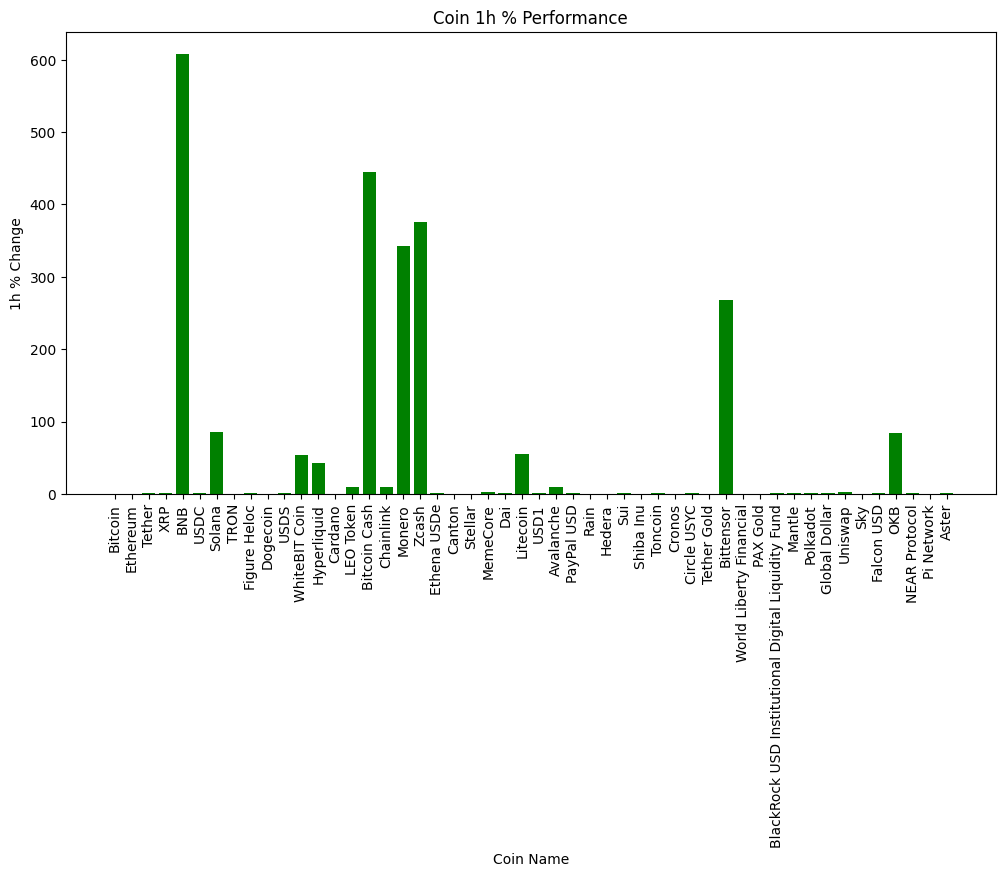

In [66]:
import matplotlib.pyplot as plt

x = df_prices["Name"]
y = df_prices["1h %"]

plt.figure(figsize=(12, 6))

plt.bar(df_prices["Name"], df_prices["1h %"], color='green')

plt.title("Coin 1h % Performance")
plt.xlabel("Coin Name")
plt.ylabel("1h % Change")

plt.xticks(rotation=90)

plt.show()

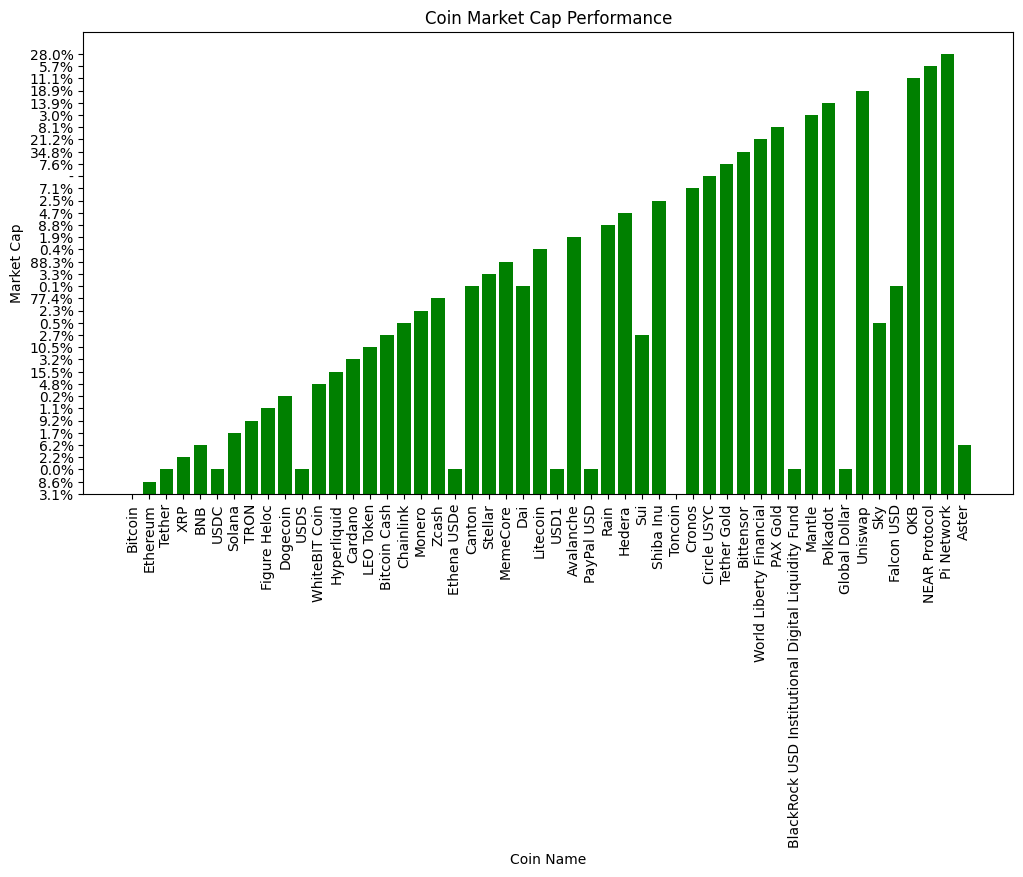

In [68]:
x = df_prices["Name"]
y = df_prices["Market Cap"]

plt.figure(figsize=(12, 6))

plt.bar(df_prices["Name"], df_prices["Market Cap"], color='green')

plt.title("Coin Market Cap Performance")
plt.xlabel("Coin Name")
plt.ylabel("Market Cap")

plt.xticks(rotation=90)

plt.show()